In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import os

os.chdir(r"C:\Users\Kaith\Desktop\Projects\E-Commerce Sales & Order Analytics\Datasets")

In [13]:
print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Projects\E-Commerce Sales & Order Analytics\Datasets
['Raw_E-Commerce_Dataset.xlsx']


In [14]:
df = pd.read_excel("Raw_E-Commerce_Dataset.xlsx")

## 1. Data Inspection

In [27]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [28]:
df.shape

(1200, 14)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [30]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [31]:
df['CouponCode'].isna().sum()

np.int64(309)

### Missing Values

The **'CouponCode'** columns contains **309** missing values. These missing values will be reviewed and handled during the data-cleaning stage.

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [34]:
df['Quantity'].describe()

count    1200.000000
mean        2.945833
std         1.407557
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

In [35]:
df[df['Quantity'] <= 0]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [36]:
df['UnitPrice'].describe()

count    1200.000000
mean      356.412750
std       197.177146
min        11.390000
25%       186.062500
50%       364.210000
75%       521.570000
max       699.930000
Name: UnitPrice, dtype: float64

In [37]:
df[df['UnitPrice'] <= 0]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [38]:
df['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

In [39]:
df[df['TotalPrice'] <= 0]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [40]:
df['Date'].min(), df['Date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-06-30 00:00:00'))

In [41]:
df['Date'].isna().sum()

np.int64(0)

### Data Inspection Summary

The E-Commerce Sales Dataset contains 1,200 records and 14 columns. Initial inspection was performed to understand the dataset structure, data types, missing values, duplicate records, and potential data-quality issues.

The following findings were identified:

* The dataset contains **1,200 records and 14 columns**.
* The `Date` column is stored as a datetime data type and contains **0 missing values**.
* `Quantity` is stored as an integer data type.
* `Unit Price` and `Total Price` are stored as floating-point numeric data types.
* The categorical fields are stored as string/object data types.
* **309 missing values** were identified in the `CouponCode` column.
* Duplicate records were checked during the inspection process.
* Quantity, Unit Price, and Total Price were checked for invalid zero or negative values.
* No immediate data-type inconsistencies were identified during the initial inspection.

The identified missing values in `CouponCode` will be addressed during the **Data Cleaning** stage.

## 2. Data Cleaning

In [2]:
import pandas as pd

In [5]:
import os

os.chdir(r"C:\Users\Kaith\Desktop\Projects\E-Commerce Sales & Order Analytics\Datasets")

In [6]:
print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Projects\E-Commerce Sales & Order Analytics\Datasets
['Raw_E-Commerce_Dataset.xlsx']


In [7]:
df = pd.read_excel("Raw_E-Commerce_Dataset.xlsx")

In [8]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [47]:
df['CouponCode'].isna().sum()

np.int64(309)

In [48]:
df['CouponCode'] = df['CouponCode'].fillna('NoCouponCode')

In [49]:
df['CouponCode'].isna().sum()

np.int64(0)

In [32]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP        313
NoCouponCode    309
WINTER15        292
SAVE10          286
Name: count, dtype: int64

### Handling Missing Coupon Codes

The **'CouponCode'** column contained 309 missing values. Since a missing coupon code indicates that no coupon was used, the missing values were replaced with **'NoCouponCode'.**

After cleaning, the **'CouponCode'** column was validated to confirm that no missing values remained.

In [50]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records

Duplicate records were checked using the **'duplicated()'** method. The dataset contains 0 duplicate records, so no duplicate rows were removed.

In [51]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [52]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [53]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [54]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [55]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP        313
NoCouponCode    309
WINTER15        292
SAVE10          286
Name: count, dtype: int64

In [56]:
df['ShippingAddress'].isna().sum()

np.int64(0)

In [57]:
df['CustomerID'].isna().sum()

np.int64(0)

In [58]:
df.columns = df.columns.str.strip()

In [59]:
df['OrderID'].isna().sum()

np.int64(0)

In [60]:
df['TrackingNumber'].isna().sum()

np.int64(0)

In [61]:
df['Quantity'].isna().sum()

np.int64(0)

In [62]:
df['UnitPrice'].isna().sum()

np.int64(0)

In [63]:
df['TotalPrice'].isna().sum()

np.int64(0)

In [64]:
df['CouponCode'].isna().sum()

np.int64(0)

In [9]:
df.to_excel("Ecommerce_Final_Dataset.xlsx", index=False)

In [10]:
print(os.path.exists("Ecommerce_Final_Dataset.xlsx"))

True


### Save the final cleaned dataset as an Excel file

## Data Cleaning

The dataset was cleaned based on the issues identified during data inspection. The 309 missing values in the `CouponCode` column were replaced with `No CouponCode`. Duplicate records and missing values in the other key fields were checked and no additional issues requiring correction were identified.

The cleaned dataset was validated to confirm that the missing `CouponCode` values were successfully handled.


## Exploratort Data Analysis (EDA)

In [67]:
import pandas as pd

In [68]:
import os

os.chdir(r"C:\Users\Kaith\Desktop\Projects\DecodeLabs_Data_Analyst_Internship\E-Commerce Sales & Order Analytics\Datasets")

In [69]:
print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Projects\DecodeLabs_Data_Analyst_Internship\E-Commerce Sales & Order Analytics\Datasets
['Ecommerce_Final_Dataset.xlsx', 'Raw_E-Commerce_Dataset.xlsx']


In [70]:
df = pd.read_excel("Ecommerce_Final_Dataset.xlsx")

In [71]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [72]:
df = df.filter(regex='^(?!Unnamed)')

In [73]:
df.shape

(1200, 14)

In [74]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [19]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [20]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [107]:
total_sales = df['TotalPrice'].sum()
total_sales

np.float64(1264761.96)

In [108]:
average_order_value = df['TotalPrice'].mean()
average_order_value

np.float64(1053.9683)

In [109]:
total_orders = df['OrderID'].nunique()
total_orders

1200

In [110]:
sales_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
sales_by_product

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [111]:
orders_by_product = df.groupby('Product')['OrderID'].nunique().sort_values(ascending=False)
orders_by_product

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: OrderID, dtype: int64

In [112]:
df['Date'] = pd.to_datetime(df['Date'])

In [114]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()
monthly_sales

Date
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

In [122]:
orders_by_payment = df.groupby('PaymentMethod')['OrderID'].nunique().sort_values(ascending=False)
orders_by_payment

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: OrderID, dtype: int64

In [123]:
orders_by_status = df.groupby('OrderStatus')['OrderID'].nunique().sort_values(ascending=False)
orders_by_status

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: OrderID, dtype: int64

In [124]:
orders_by_referral = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
orders_by_referral

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [126]:
orders_by_coupon = df.groupby('CouponCode')['TotalPrice'].sum().sort_values(ascending=False)
orders_by_coupon

CouponCode
FREESHIP     335036.99
NO COUPON    322401.41
SAVE10       304840.02
WINTER15     302483.54
Name: TotalPrice, dtype: float64

In [127]:
quantity_by_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
quantity_by_product

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

In [128]:
sales_by_status = df.groupby('OrderStatus')['TotalPrice'].sum().sort_values(ascending=False)
sales_by_status

OrderStatus
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: TotalPrice, dtype: float64

In [135]:
sales_by_referral = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
sales_by_referral

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [144]:
sales_by_coupon = df.groupby('CouponCode')['TotalPrice'].sum().sort_values(ascending=False)
sales_by_coupon

CouponCode
FREESHIP     335036.99
NO COUPON    322401.41
SAVE10       304840.02
WINTER15     302483.54
Name: TotalPrice, dtype: float64

In [129]:
avg_order_by_product = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)
avg_order_by_product

Product
Laptop     1110.558150
Chair      1098.989382
Printer    1080.732652
Monitor    1077.616012
Tablet     1042.284637
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Date'>

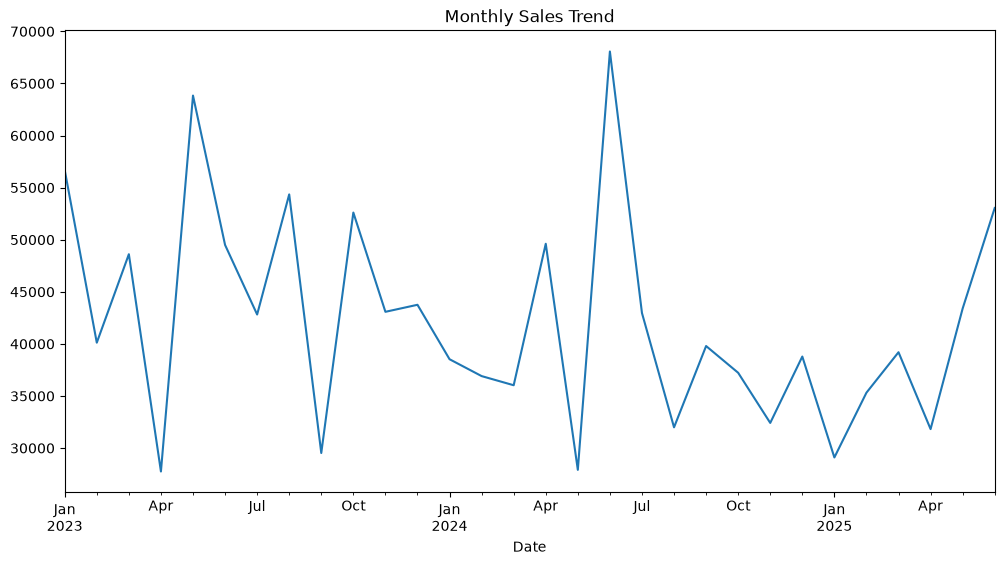

In [138]:
monthly_sales.plot(kind='line', figsize=(12, 6), title='Monthly Sales Trend')

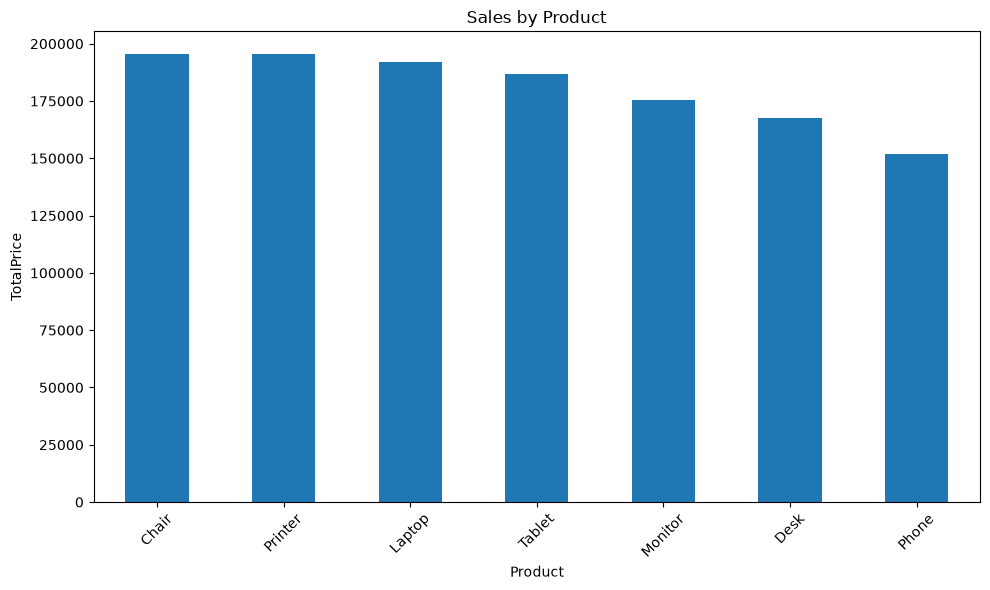

In [130]:
sales_by_product.plot(kind='bar', figsize=(10, 6), title='Sales by Product')

plt.xlabel('Product')
plt.ylabel('TotalPrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

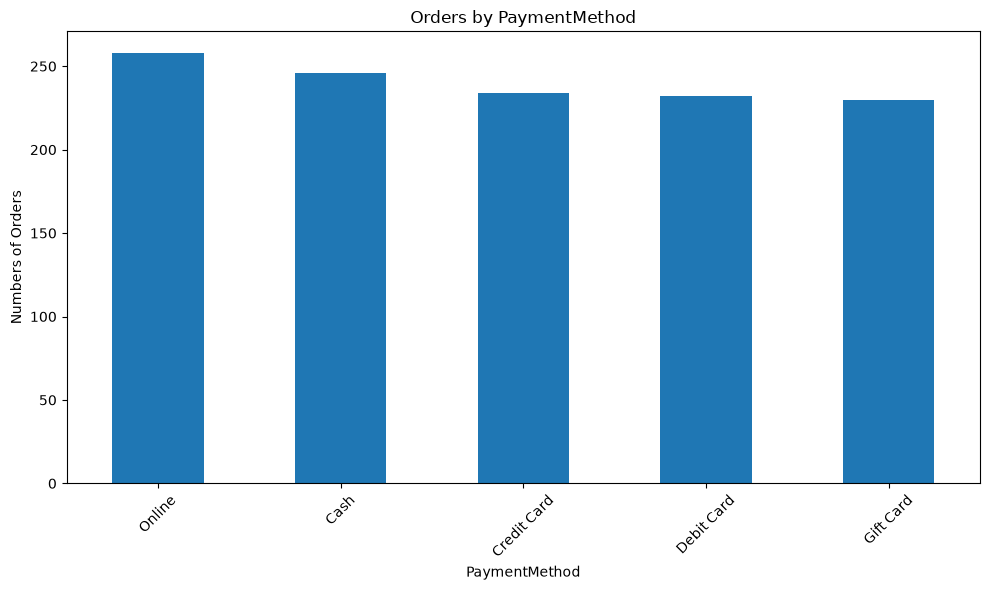

In [131]:
orders_by_payment.plot(kind='bar', figsize=(10, 6), title='Orders by PaymentMethod')

plt.xlabel('PaymentMethod')
plt.ylabel('Numbers of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

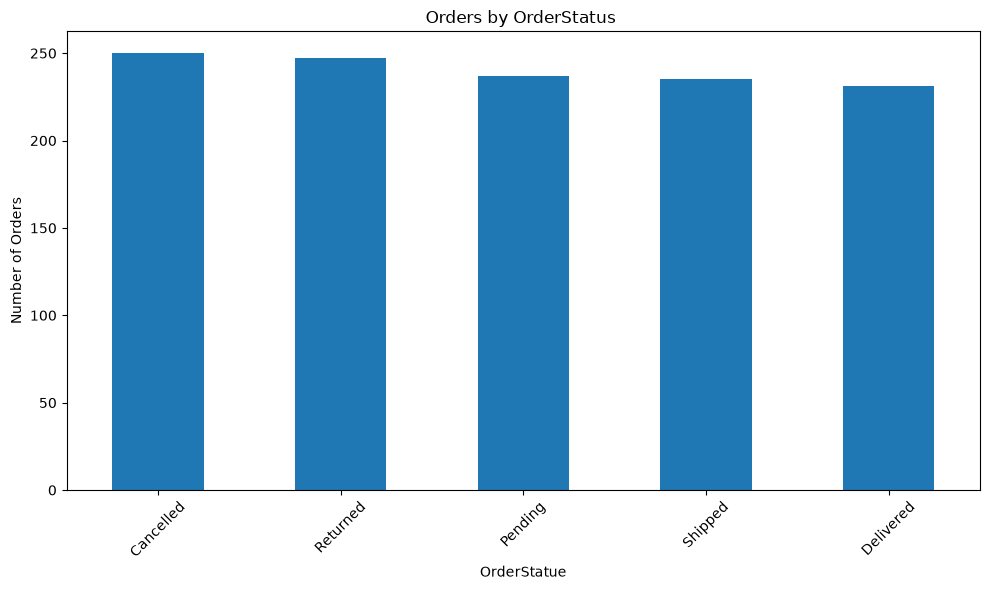

In [132]:
orders_by_status.plot(kind='bar', figsize=(10, 6), title='Orders by OrderStatus ')

plt.xlabel('OrderStatue')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

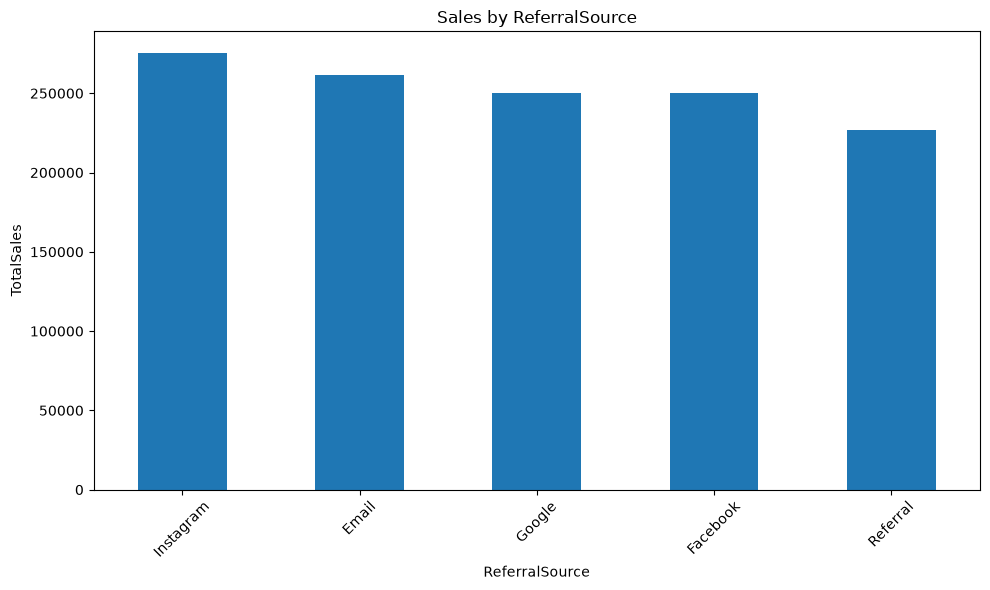

In [136]:
sales_by_referral.plot(kind='bar', figsize=(10, 6), title='Sales by ReferralSource')

plt.xlabel('ReferralSource')
plt.ylabel('TotalSales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

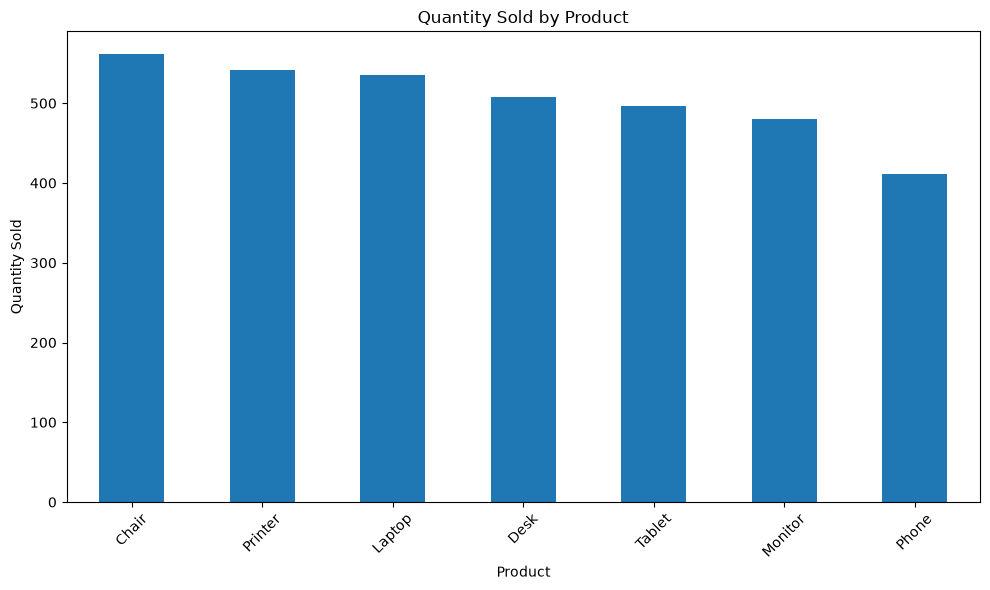

In [142]:
quantity_by_product.plot(kind='bar', figsize=(10, 6), title='Quantity Sold by Product')

plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

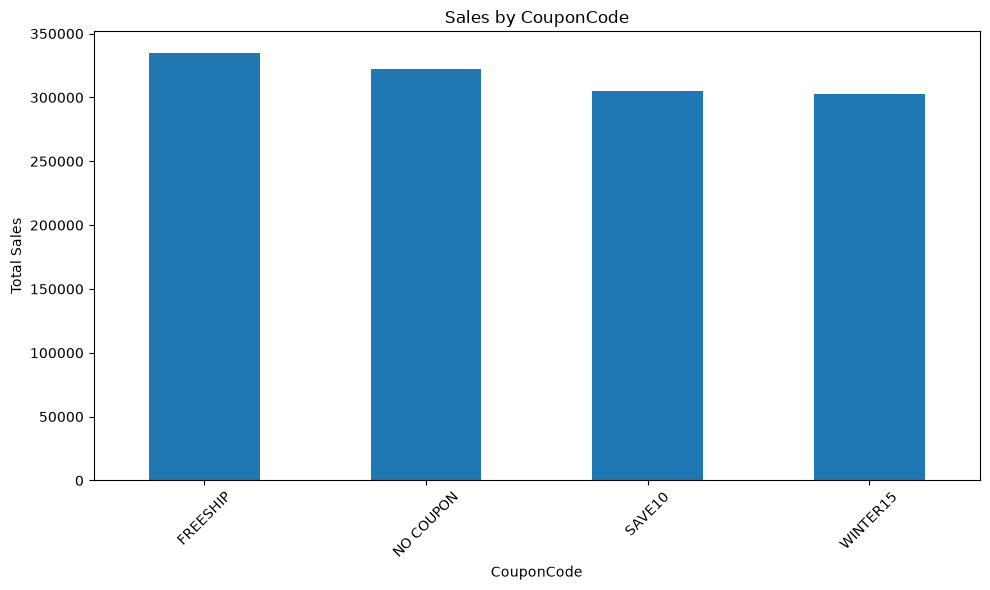

In [145]:
sales_by_coupon.plot(kind='bar', figsize=(10, 6), title='Sales by CouponCode')

plt.xlabel('CouponCode')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
print("Top Product by Sales:")
print(sales_by_product.idxmax(), sales_by_product.max())

print("\nTop Product by Quantity:")
print(quantity_by_product.idxmax(), quantity_by_product.max())

print("\nTop ReferralSource by Sales:")
print(sales_by_referral.idxmax(), sales_by_referral.max())

print("\nTop CouponCode by Sales:")
print(sales_by_coupon.idxmax(), sales_by_coupon.max())

Top Product by Sales:
Chair 195620.11

Top Product by Quantity:
Chair 562

Top ReferralSource by Sales:
Instagram 275285.45

Top CouponCode by Sales:
FREESHIP 335036.99


## EDA Key Finding

- Total sales amounted to **12,647,761.96** across **1,200 orders.**
- The average order value was **1,053.97.**
- **Chair** generated the highest sales at **1,956,281.11.**
- **Chair** also had the highest quantity sold, with **562 units.**
- **Instagram** was the top referral source by sales.
- **Free Shipping** generated the highest sales among the coupon categories.
- Monthly sales showed variations over the analyzed period, highlighting the changes in sales perfomance over time.